In [1]:
from pathlib import Path
import sys
 
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import umap
import json
import pandas as pd
 
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.stats import ttest_rel
 
from src.utils.seed import set_seed
from src.data.bnci_loader import load_bnci_all_subjects
from src.models.deepconvnet import DeepConvNet
from src.losses.icrr_loss import icrr_loss
from src.evaluation.ess import compute_ess

In [5]:
SEED       = 42
set_seed(SEED)
 
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [6]:
BATCH_SIZE  = 64
EPOCHS      = 50
LR          = 1e-3
 
LAMBDA_ICRR = 0.1
 

In [7]:
DATA_DIR    = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"
 
TABLES_DIR  = RESULTS_DIR / "tables"  / "icrr_loso_poc"
FIGURES_DIR = RESULTS_DIR / "figures" / "icrr_loso_poc"
 
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
 
DATA_PATH   = DATA_DIR / "bnci_dataset" / "processed" / "preprocessed_BNCI_all_subjects.npz"

In [8]:
X, y, subjects, meta = load_bnci_all_subjects(DATA_PATH)
 
chans           = X.shape[1]
samples         = X.shape[2]
n_classes       = len(np.unique(y))
unique_subjects = np.unique(subjects)
 
print("Dataset shape :", X.shape)
print("Subjects      :", unique_subjects)
print("Classes       :", np.unique(y))
print("Trials/subject:", {int(s): int((subjects == s).sum()) for s in unique_subjects})

Dataset shape : (5184, 25, 561)
Subjects      : [0 1 2 3 4 5 6 7 8]
Classes       : [0 1 2 3]
Trials/subject: {0: 576, 1: 576, 2: 576, 3: 576, 4: 576, 5: 576, 6: 576, 7: 576, 8: 576}


In [9]:
def train_backbone(backbone, X_train, y_train, lambda_icrr=0.0):
    """
    Train DeepConvNet backbone directly.
    - lambda_icrr=0.0 : cross-entropy only (CE baseline)
    - lambda_icrr>0.0 : cross-entropy + ICRR regularisation on backbone embeddings
    No projection head — classifier operates on backbone embeddings directly.
    """
    backbone.train()
 
    optimizer = optim.Adam(backbone.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
 
    dataset = TensorDataset(
        torch.tensor(X_train).float(),
        torch.tensor(y_train).long()
    )
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
 
    for epoch in range(EPOCHS):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
 
            # Return backbone embeddings for ICRR; logits used for CE
            logits, z = backbone(xb, return_embedding=True)
            ce_loss   = criterion(logits, yb)
 
            if lambda_icrr > 0:
                # ICRR operates on backbone embeddings, not on classifier output
                loss = ce_loss + lambda_icrr * icrr_loss(z, yb)
            else:
                loss = ce_loss
 
            loss.backward()
            optimizer.step()
 
 

In [10]:
def evaluate_backbone(backbone, X_test, y_test):
    """
    Evaluate backbone on held-out set.
    Returns accuracy, ESS (backbone space), and raw backbone embeddings.
    ESS is measured in backbone space because that is where ICRR acts.
    """
    backbone.eval()
 
    all_preds      = []
    all_embeddings = []
 
    dataset = TensorDataset(
        torch.tensor(X_test).float(),
        torch.tensor(y_test).long()
    )
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
 
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            logits, z = backbone(xb, return_embedding=True)
            all_preds.append(torch.argmax(logits, dim=1).cpu().numpy())
            all_embeddings.append(z.cpu().numpy())
 
    preds      = np.concatenate(all_preds)
    embeddings = np.concatenate(all_embeddings)
 
    acc = accuracy_score(y_test, preds)
    ess = compute_ess(embeddings, y_test)
 
    return acc, ess, embeddings
 

In [11]:
# %%
fold_results = []
all_emb_ce   = []
all_emb_icrr = []
all_labels   = []
 
for fold, test_subject in enumerate(unique_subjects):
 
    print(f"\nFold {fold+1}/{len(unique_subjects)} | Test subject: {test_subject}")
 
    train_idx = subjects != test_subject
    test_idx  = subjects == test_subject
 
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
 
    # ── CE baseline ───────────────────────────────────────────────────────────
    # Seed is set per fold so both models start from identical random weights.
    # This makes the CE vs ICRR comparison purely a function of the loss, not
    # random initialisation differences.
    set_seed(SEED + fold)
    backbone_ce = DeepConvNet(chans, samples, n_classes).to(DEVICE)
    train_backbone(backbone_ce, X_train, y_train, lambda_icrr=0.0)
    acc_ce, ess_ce, emb_ce = evaluate_backbone(backbone_ce, X_test, y_test)
 
    # ── CE + ICRR ─────────────────────────────────────────────────────────────
    set_seed(SEED + fold)   # identical init as CE model for fair comparison
    backbone_icrr = DeepConvNet(chans, samples, n_classes).to(DEVICE)
    train_backbone(backbone_icrr, X_train, y_train, lambda_icrr=LAMBDA_ICRR)
    acc_icrr, ess_icrr, emb_icrr = evaluate_backbone(backbone_icrr, X_test, y_test)
 
    print(f"  CE   → acc: {acc_ce:.4f}   ESS: {ess_ce:.4f}")
    print(f"  ICRR → acc: {acc_icrr:.4f}   ESS: {ess_icrr:.4f}")
 
    fold_results.append({
        "subject"  : int(test_subject),
        "acc_ce"   : acc_ce,
        "acc_icrr" : acc_icrr,
        "ess_ce"   : ess_ce,
        "ess_icrr" : ess_icrr,
    })
 
    all_emb_ce.append(emb_ce)
    all_emb_icrr.append(emb_icrr)
    all_labels.append(y_test)
 
# ── Aggregate ─────────────────────────────────────────────────────────────────
df          = pd.DataFrame(fold_results)
emb_ce_all   = np.concatenate(all_emb_ce)
emb_icrr_all = np.concatenate(all_emb_icrr)
labels_all   = np.concatenate(all_labels)
 
print("\n\n===== LOSO FOLD SUMMARY =====")
print(df.to_string(index=False))


Fold 1/9 | Test subject: 0
  CE   → acc: 0.5069   ESS: 15.5983
  ICRR → acc: 0.4983   ESS: 13.6671

Fold 2/9 | Test subject: 1
  CE   → acc: 0.4514   ESS: 11.5689
  ICRR → acc: 0.4705   ESS: 9.3484

Fold 3/9 | Test subject: 2
  CE   → acc: 0.5885   ESS: 11.7293
  ICRR → acc: 0.5903   ESS: 10.4481

Fold 4/9 | Test subject: 3
  CE   → acc: 0.5017   ESS: 20.2533
  ICRR → acc: 0.5191   ESS: 16.1822

Fold 5/9 | Test subject: 4
  CE   → acc: 0.4462   ESS: 17.4291
  ICRR → acc: 0.4132   ESS: 15.2847

Fold 6/9 | Test subject: 5
  CE   → acc: 0.3889   ESS: 14.7929
  ICRR → acc: 0.4253   ESS: 12.8613

Fold 7/9 | Test subject: 6
  CE   → acc: 0.7205   ESS: 15.5829
  ICRR → acc: 0.6944   ESS: 14.3276

Fold 8/9 | Test subject: 7
  CE   → acc: 0.7483   ESS: 21.3406
  ICRR → acc: 0.7031   ESS: 19.9446

Fold 9/9 | Test subject: 8
  CE   → acc: 0.5781   ESS: 16.3874
  ICRR → acc: 0.5816   ESS: 14.5416


===== LOSO FOLD SUMMARY =====
 subject   acc_ce  acc_icrr    ess_ce  ess_icrr
       0 0.506944  0.

In [12]:
def cohens_d_paired(a, b):
    """Paired Cohen's d: effect size for within-subject (paired) comparison."""
    diff = np.asarray(a) - np.asarray(b)
    return diff.mean() / diff.std(ddof=1)
 
# Paired t-tests across subjects
# Accuracy: two-sided (ICRR might help or hurt)
# ESS: one-sided framing — we expect CE > ICRR (more compact)
_, p_acc = ttest_rel(df["acc_icrr"],  df["acc_ce"])
_, p_ess = ttest_rel(df["ess_ce"],    df["ess_icrr"])
 
d_acc = cohens_d_paired(df["acc_icrr"].values, df["acc_ce"].values)
d_ess = cohens_d_paired(df["ess_ce"].values,   df["ess_icrr"].values)
 
ess_reduction_pct = (
    (df["ess_ce"].mean() - df["ess_icrr"].mean()) / df["ess_ce"].mean() * 100
)
 
print("===== STATISTICAL SUMMARY (LOSO, 9 subjects) =====")
print(f"\nAccuracy")
print(f"  CE   : {df['acc_ce'].mean():.4f}  ±  {df['acc_ce'].std():.4f}")
print(f"  ICRR : {df['acc_icrr'].mean():.4f}  ±  {df['acc_icrr'].std():.4f}")
print(f"  Δ    : {df['acc_icrr'].mean() - df['acc_ce'].mean():+.4f}   p={p_acc:.4f}   d={d_acc:.3f}")
 
print(f"\nESS (backbone space, lower = more compact)")
print(f"  CE   : {df['ess_ce'].mean():.4f}  ±  {df['ess_ce'].std():.4f}")
print(f"  ICRR : {df['ess_icrr'].mean():.4f}  ±  {df['ess_icrr'].std():.4f}")
print(f"  Δ    : {df['ess_icrr'].mean() - df['ess_ce'].mean():+.4f}   p={p_ess:.4f}   d={d_ess:.3f}")
print(f"  ESS reduction: {ess_reduction_pct:.1f}%")
 
# ── Save ──────────────────────────────────────────────────────────────────────
summary = {
    "lambda_icrr"       : LAMBDA_ICRR,
    "mean_acc_ce"       : float(df["acc_ce"].mean()),
    "std_acc_ce"        : float(df["acc_ce"].std()),
    "mean_acc_icrr"     : float(df["acc_icrr"].mean()),
    "std_acc_icrr"      : float(df["acc_icrr"].std()),
    "mean_ess_ce"       : float(df["ess_ce"].mean()),
    "std_ess_ce"        : float(df["ess_ce"].std()),
    "mean_ess_icrr"     : float(df["ess_icrr"].mean()),
    "std_ess_icrr"      : float(df["ess_icrr"].std()),
    "p_acc"             : float(p_acc),
    "p_ess"             : float(p_ess),
    "cohens_d_acc"      : float(d_acc),
    "cohens_d_ess"      : float(d_ess),
    "ess_reduction_pct" : float(ess_reduction_pct),
}
 
with open(TABLES_DIR / "loso_poc_summary.json", "w") as f:
    json.dump(summary, f, indent=4)
 
df.to_csv(TABLES_DIR / "loso_poc_per_subject.csv", index=False)

===== STATISTICAL SUMMARY (LOSO, 9 subjects) =====

Accuracy
  CE   : 0.5478  ±  0.1231
  ICRR : 0.5440  ±  0.1065
  Δ    : -0.0039   p=0.6775   d=-0.144

ESS (backbone space, lower = more compact)
  CE   : 16.0759  ±  3.3245
  ICRR : 14.0673  ±  3.1179
  Δ    : -2.0086   p=0.0001   d=2.353
  ESS reduction: 12.5%


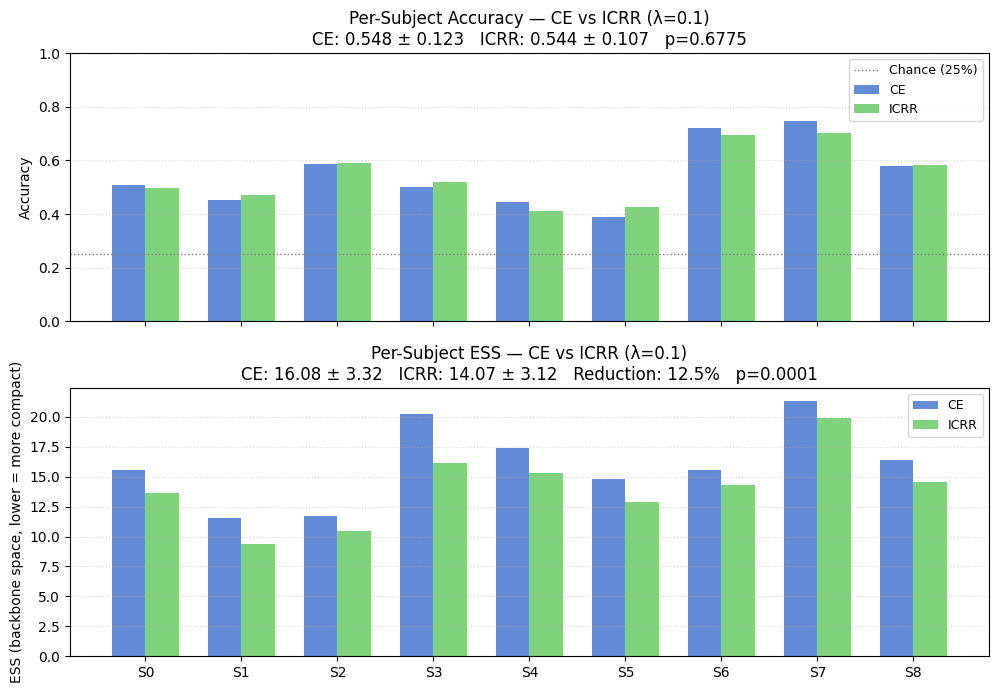

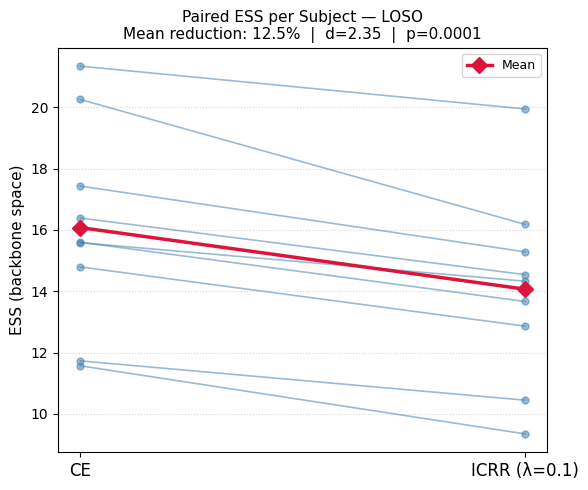

Fitting shared UMAP reducer on combined embeddings...


c:\Users\Amrita\Desktop\VS_code\eeg_representation_geometry\eegvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


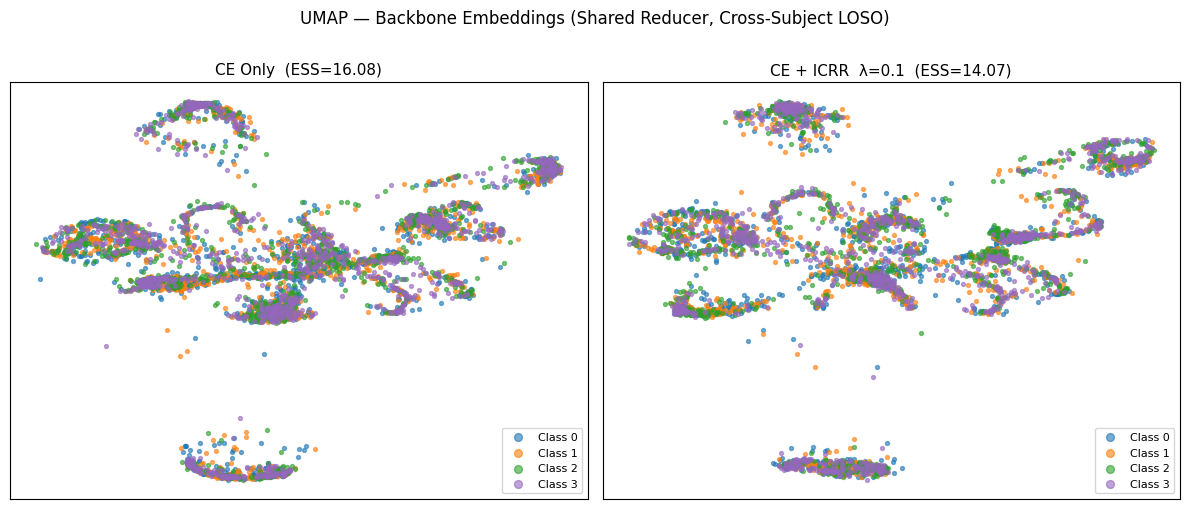

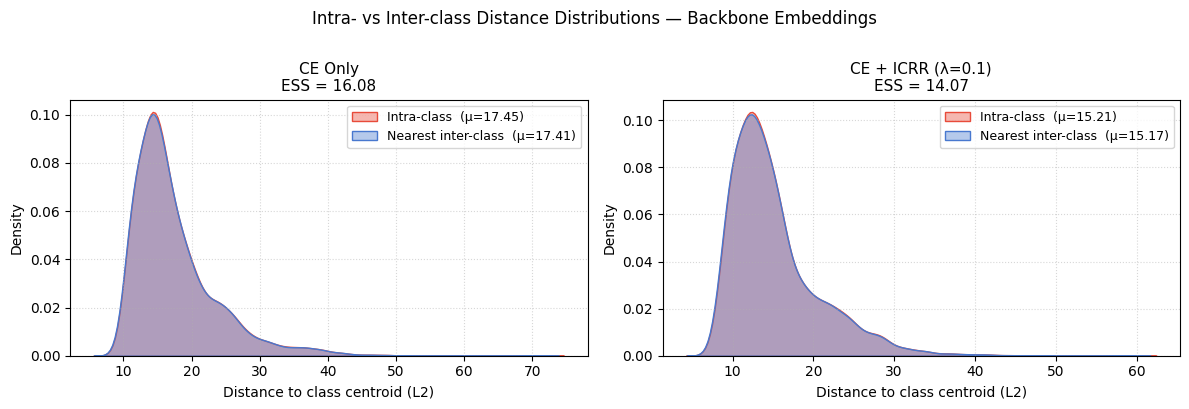

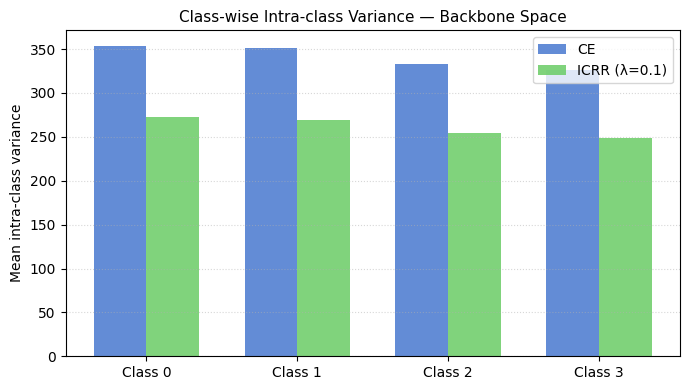

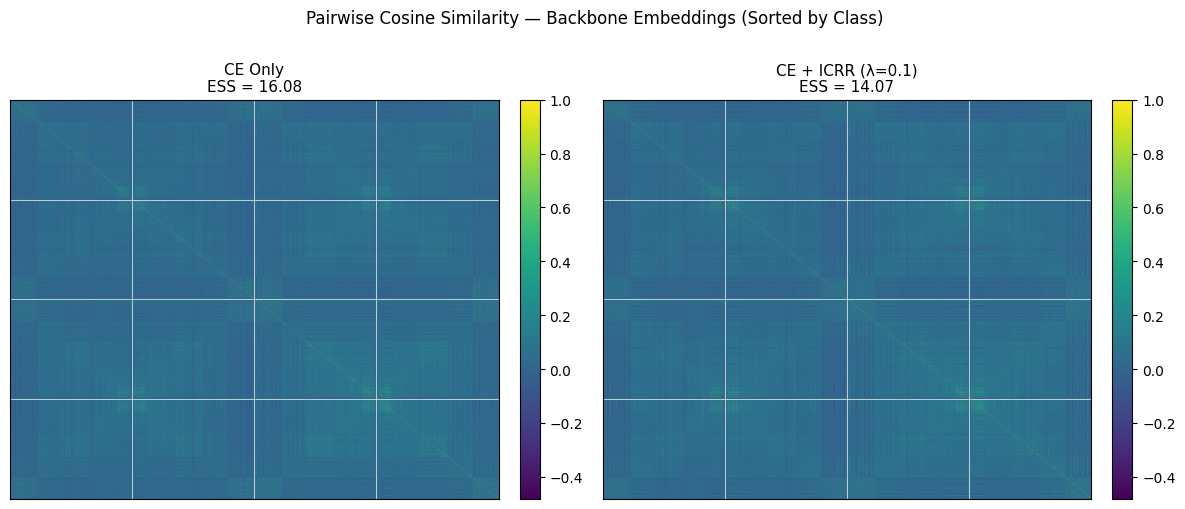

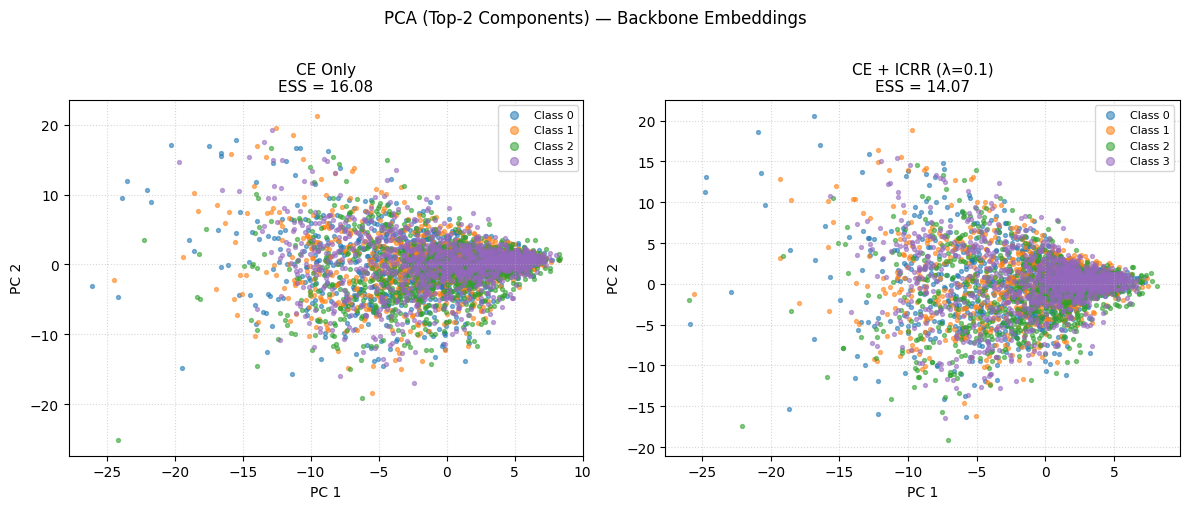

In [13]:
subjects_list = df["subject"].tolist()
x = np.arange(len(subjects_list))
width = 0.35
 
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
 
# ── Accuracy ──────────────────────────────────────────────────────────────────
axes[0].bar(x - width/2, df["acc_ce"],   width, label="CE",   color="#4878CF", alpha=0.85)
axes[0].bar(x + width/2, df["acc_icrr"], width, label="ICRR", color="#6ACC65", alpha=0.85)
axes[0].axhline(0.25, color="grey", linestyle=":", linewidth=1, label="Chance (25%)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title(
    f"Per-Subject Accuracy — CE vs ICRR (λ={LAMBDA_ICRR})\n"
    f"CE: {df['acc_ce'].mean():.3f} ± {df['acc_ce'].std():.3f}   "
    f"ICRR: {df['acc_icrr'].mean():.3f} ± {df['acc_icrr'].std():.3f}   "
    f"p={p_acc:.4f}"
)
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
 
# ── ESS ───────────────────────────────────────────────────────────────────────
axes[1].bar(x - width/2, df["ess_ce"],   width, label="CE",   color="#4878CF", alpha=0.85)
axes[1].bar(x + width/2, df["ess_icrr"], width, label="ICRR", color="#6ACC65", alpha=0.85)
axes[1].set_ylabel("ESS (backbone space, lower = more compact)")
axes[1].set_title(
    f"Per-Subject ESS — CE vs ICRR (λ={LAMBDA_ICRR})\n"
    f"CE: {df['ess_ce'].mean():.2f} ± {df['ess_ce'].std():.2f}   "
    f"ICRR: {df['ess_icrr'].mean():.2f} ± {df['ess_icrr'].std():.2f}   "
    f"Reduction: {ess_reduction_pct:.1f}%   p={p_ess:.4f}"
)
axes[1].legend(loc="upper right", fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"S{s}" for s in subjects_list])
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_per_subject_acc_ess.png", dpi=300, bbox_inches="tight")
plt.show()
 
# %% [markdown]
# ### 7.2 Paired ESS: Subject-Level Effect
#
# Each line connects one subject's CE ESS to its ICRR ESS.
# A consistent downward slope across all subjects confirms the ESS reduction
# is not driven by a few outlier subjects.
 
# %%
fig, ax = plt.subplots(figsize=(6, 5))
 
for _, row in df.iterrows():
    ax.plot(
        [0, 1],
        [row["ess_ce"], row["ess_icrr"]],
        color="steelblue", alpha=0.55, linewidth=1.2, marker="o", markersize=5
    )
 
# Means
ax.plot([0, 1], [df["ess_ce"].mean(), df["ess_icrr"].mean()],
        color="crimson", linewidth=2.5, marker="D", markersize=8, label="Mean", zorder=5)
 
ax.set_xticks([0, 1])
ax.set_xticklabels(["CE", f"ICRR (λ={LAMBDA_ICRR})"], fontsize=12)
ax.set_ylabel("ESS (backbone space)", fontsize=11)
ax.set_title(
    f"Paired ESS per Subject — LOSO\n"
    f"Mean reduction: {ess_reduction_pct:.1f}%  |  d={d_ess:.2f}  |  p={p_ess:.4f}",
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_paired_ess_subjects.png", dpi=300, bbox_inches="tight")
plt.show()
 
# %% [markdown]
# ### 7.3 UMAP — Backbone Representation Space
#
# A single UMAP reducer is fitted on the combined CE and ICRR embeddings so
# both are projected into the same 2D space. This makes the comparison valid —
# the spatial layout is not independently rescaled for each condition.
# Points are coloured by class label.
 
# %%
print("Fitting shared UMAP reducer on combined embeddings...")
 
combined = np.concatenate([emb_ce_all, emb_icrr_all])
 
reducer = umap.UMAP(
    n_neighbors=50,
    min_dist=0.01,
    metric="euclidean",
    random_state=SEED
)
reducer.fit(combined)
 
umap_ce   = reducer.transform(emb_ce_all)
umap_icrr = reducer.transform(emb_icrr_all)
 
print("UMAP done.")
 
# %%
class_colors = plt.cm.tab10(np.linspace(0, 0.4, n_classes))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, umap_emb, title in zip(
    axes,
    [umap_ce, umap_icrr],
    [f"CE Only  (ESS={df['ess_ce'].mean():.2f})",
     f"CE + ICRR  λ={LAMBDA_ICRR}  (ESS={df['ess_icrr'].mean():.2f})"]
):
    for cls in range(n_classes):
        mask = labels_all == cls
        ax.scatter(
            umap_emb[mask, 0], umap_emb[mask, 1],
            s=8, alpha=0.6, label=f"Class {cls}", color=class_colors[cls]
        )
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]);  ax.set_yticks([])
    ax.legend(fontsize=8, markerscale=2, loc="lower right")
 
fig.suptitle(
    "UMAP — Backbone Embeddings (Shared Reducer, Cross-Subject LOSO)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_umap_ce_vs_icrr.png", dpi=300, bbox_inches="tight")
plt.show()
 
# %% [markdown]
# ### 7.4 Intra-class vs Inter-class Distance Distributions
#
# This is the most direct geometric test of ICRR's claim.
# Intra-class distance = distance from each sample to its class centroid.
# Inter-class distance = distance from each sample to the nearest *other* class centroid.
#
# ICRR should compress intra-class distances (tighter clusters) while
# inter-class distances remain stable or increase.
 
# %%
def compute_centroid_distances(embeddings, labels):
    """
    Returns per-sample intra-class and nearest-inter-class centroid distances.
    Uses L2 distance to class centroids.
    """
    classes   = np.unique(labels)
    centroids = {c: embeddings[labels == c].mean(axis=0) for c in classes}
 
    intra, inter = [], []
    for i, emb in enumerate(embeddings):
        c = labels[i]
        intra.append(np.linalg.norm(emb - centroids[c]))
        inter.append(min(
            np.linalg.norm(emb - centroids[other])
            for other in classes if other != c
        ))
    return np.array(intra), np.array(inter)
 
 
intra_ce,   inter_ce   = compute_centroid_distances(emb_ce_all,   labels_all)
intra_icrr, inter_icrr = compute_centroid_distances(emb_icrr_all, labels_all)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
 
palette = {"Intra-class": "#E84B3A", "Nearest inter-class": "#4878CF"}
 
for ax, (intra, inter), title, ess_val in zip(
    axes,
    [(intra_ce, inter_ce), (intra_icrr, inter_icrr)],
    ["CE Only", f"CE + ICRR (λ={LAMBDA_ICRR})"],
    [df["ess_ce"].mean(), df["ess_icrr"].mean()]
):
    sns.kdeplot(intra, fill=True, alpha=0.4, color=palette["Intra-class"],
                label=f"Intra-class  (μ={intra.mean():.2f})", ax=ax)
    sns.kdeplot(inter, fill=True, alpha=0.4, color=palette["Nearest inter-class"],
                label=f"Nearest inter-class  (μ={inter.mean():.2f})", ax=ax)
    ax.set_title(f"{title}\nESS = {ess_val:.2f}", fontsize=11)
    ax.set_xlabel("Distance to class centroid (L2)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(linestyle=":", alpha=0.5)
 
fig.suptitle(
    "Intra- vs Inter-class Distance Distributions — Backbone Embeddings",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_distance_kde.png", dpi=300, bbox_inches="tight")
plt.show()
 
# %% [markdown]
# ### 7.5 Class-wise Intra-class Variance
#
# Breakdown of intra-class compactness per individual class.
# A consistent reduction across all classes confirms ICRR is not compressing
# one class at the expense of others.
 
# %%
classes = np.unique(labels_all)
 
ce_var_per_class   = []
icrr_var_per_class = []
 
for c in classes:
    mask = labels_all == c
    ce_centroid   = emb_ce_all[mask].mean(axis=0)
    icrr_centroid = emb_icrr_all[mask].mean(axis=0)
 
    ce_var   = np.mean(np.sum((emb_ce_all[mask]   - ce_centroid)   ** 2, axis=1))
    icrr_var = np.mean(np.sum((emb_icrr_all[mask] - icrr_centroid) ** 2, axis=1))
 
    ce_var_per_class.append(ce_var)
    icrr_var_per_class.append(icrr_var)
 
x_cls = np.arange(n_classes)
fig, ax = plt.subplots(figsize=(7, 4))
 
ax.bar(x_cls - width/2, ce_var_per_class,   width, label="CE",   color="#4878CF", alpha=0.85)
ax.bar(x_cls + width/2, icrr_var_per_class, width, label=f"ICRR (λ={LAMBDA_ICRR})",
       color="#6ACC65", alpha=0.85)
 
ax.set_xticks(x_cls)
ax.set_xticklabels([f"Class {c}" for c in classes])
ax.set_ylabel("Mean intra-class variance")
ax.set_title("Class-wise Intra-class Variance — Backbone Space", fontsize=11)
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_classwise_variance.png", dpi=300, bbox_inches="tight")
plt.show()
 
# %% [markdown]
# ### 7.6 Pairwise Cosine Similarity Heatmaps
#
# Samples are sorted by class label before computing pairwise cosine similarity.
# The block-diagonal structure reflects intra-class cohesion.
# A sharper block-diagonal in the ICRR panel indicates that same-class
# embeddings are more similar (consistent) to each other.
 
# %%
sort_idx       = np.argsort(labels_all)
labels_sorted  = labels_all[sort_idx]
emb_ce_sorted  = emb_ce_all[sort_idx]
emb_icrr_sorted = emb_icrr_all[sort_idx]
 
sim_ce   = cosine_similarity(emb_ce_sorted)
sim_icrr = cosine_similarity(emb_icrr_sorted)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, sim, title, ess_val in zip(
    axes,
    [sim_ce, sim_icrr],
    ["CE Only", f"CE + ICRR (λ={LAMBDA_ICRR})"],
    [df["ess_ce"].mean(), df["ess_icrr"].mean()]
):
    im = ax.imshow(sim, cmap="viridis", aspect="auto", vmin=sim_ce.min(), vmax=1.0)
    # Draw class boundary lines
    boundaries = np.where(np.diff(labels_sorted))[0] + 1
    for b in boundaries:
        ax.axhline(b - 0.5, color="white", linewidth=0.6, alpha=0.8)
        ax.axvline(b - 0.5, color="white", linewidth=0.6, alpha=0.8)
    ax.set_title(f"{title}\nESS = {ess_val:.2f}", fontsize=11)
    ax.set_xticks([]);  ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
 
fig.suptitle(
    "Pairwise Cosine Similarity — Backbone Embeddings (Sorted by Class)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_cosine_similarity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
 
# %% [markdown]
# ### 7.7 PCA — Top-2 Principal Components
#
# Linear projection using PCA fitted independently on each condition.
# Unlike UMAP, PCA is deterministic and preserves global variance structure.
# It shows whether the compactness effect visible in UMAP is also present
# in a linear projection — i.e. not an artefact of UMAP's non-linear layout.
 
# %%
from sklearn.decomposition import PCA
 
pca_ce   = PCA(n_components=2, random_state=SEED).fit_transform(emb_ce_all)
pca_icrr = PCA(n_components=2, random_state=SEED).fit_transform(emb_icrr_all)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, pca_emb, title, ess_val in zip(
    axes,
    [pca_ce, pca_icrr],
    ["CE Only", f"CE + ICRR (λ={LAMBDA_ICRR})"],
    [df["ess_ce"].mean(), df["ess_icrr"].mean()]
):
    for cls in range(n_classes):
        mask = labels_all == cls
        ax.scatter(
            pca_emb[mask, 0], pca_emb[mask, 1],
            s=8, alpha=0.55, label=f"Class {cls}", color=class_colors[cls]
        )
    ax.set_title(f"{title}\nESS = {ess_val:.2f}", fontsize=11)
    ax.set_xlabel("PC 1");  ax.set_ylabel("PC 2")
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(linestyle=":", alpha=0.5)
 
fig.suptitle(
    "PCA (Top-2 Components) — Backbone Embeddings",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_pca_ce_vs_icrr.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
print("=" * 60)
print("NOTEBOOK 06 — FINAL SUMMARY")
print("Architecture : DeepConvNet backbone, no projection head")
print(f"Protocol     : LOSO cross-subject ({len(unique_subjects)} subjects)")
print(f"Lambda ICRR  : {LAMBDA_ICRR} (proof-of-concept; sweep in NB07)")
print("=" * 60)
 
print(f"\nAccuracy")
print(f"  CE   : {df['acc_ce'].mean():.4f}  ±  {df['acc_ce'].std():.4f}")
print(f"  ICRR : {df['acc_icrr'].mean():.4f}  ±  {df['acc_icrr'].std():.4f}")
print(f"  Δ acc: {df['acc_icrr'].mean() - df['acc_ce'].mean():+.4f}")
print(f"  p    : {p_acc:.4f}   Cohen's d = {d_acc:.3f}")
 
print(f"\nEmbedding Stability Score (backbone space, lower = more compact)")
print(f"  CE   : {df['ess_ce'].mean():.4f}  ±  {df['ess_ce'].std():.4f}")
print(f"  ICRR : {df['ess_icrr'].mean():.4f}  ±  {df['ess_icrr'].std():.4f}")
print(f"  Δ ESS: {df['ess_icrr'].mean() - df['ess_ce'].mean():+.4f}  ({ess_reduction_pct:.1f}% reduction)")
print(f"  p    : {p_ess:.4f}   Cohen's d = {d_ess:.3f}")
 
print("\nNext step: NB07 — lambda sweep for ICRR-alone (backbone, no projection)")
print("=" * 60)

NOTEBOOK 06 — FINAL SUMMARY
Architecture : DeepConvNet backbone, no projection head
Protocol     : LOSO cross-subject (9 subjects)
Lambda ICRR  : 0.1 (proof-of-concept; sweep in NB07)

Accuracy
  CE   : 0.5478  ±  0.1231
  ICRR : 0.5440  ±  0.1065
  Δ acc: -0.0039
  p    : 0.6775   Cohen's d = -0.144

Embedding Stability Score (backbone space, lower = more compact)
  CE   : 16.0759  ±  3.3245
  ICRR : 14.0673  ±  3.1179
  Δ ESS: -2.0086  (12.5% reduction)
  p    : 0.0001   Cohen's d = 2.353

Next step: NB07 — lambda sweep for ICRR-alone (backbone, no projection)
